In [91]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import locale
import seaborn as sns
import matplotlib.pyplot as plt
import re
import pyproj
import folium

In [92]:
#Filtros de fechas

dia_ivd = '20260501'
dia_fvd = '20260531'

mes = 'may'

Rutas

In [93]:
rutas = pd.DataFrame({
    'Id Linea': [
        10311, 10350, 10550, 10266, 10342, 10360, 10354, 10690, 10331,
        10264, 10689, 10325, 10305, 10688, 10273, 10244, 10261, 10204,
        10691, 10196, 10184, 10310, 10304, 10194, 10232, 10292, 10551,
        10282, 10339
    ],
    'Nombre Linea': [
        'DA213', 'SE14', 'P500', 'DD204', 'KB309', '5-abr', '16-may', 'DL219', '12',
        '614', 'DH216', '576', 'DD212', 'BD237', '142', 'SE10', '466', '402',
        'DA218', 'E25', '740', 'C101', '806', '539', '359', '577', 'KL307',
        'DH209', 'C25'
    ]
})

rutas.head()

,Id Linea,Nombre Linea
0,10311,DA213
1,10350,SE14
2,10550,P500
3,10266,DD204
4,10342,KB309


Datos brutos de acciones

In [94]:
# Ruta de la carpeta que contiene los archivos de desglosados troncal
ruta_carpeta = 'Z:/01 base_datos/41 Informe Diario CCZ/FMS 2025/Datos diarios dia vencido FMS/datos brutos'

# Fechas de inicio y fin para el filtro
fecha_inicio = f'{dia_ivd}'
fecha_fin = f'{dia_fvd}'

# Lista para almacenar los DataFrames
dataframes = []

# Recorrer todos los archivos en la carpeta
for nombre_archivo in os.listdir(ruta_carpeta):
    if nombre_archivo.endswith('_datos_brutos.xlsx'):
        # Extraer la fecha del nombre del archivo
        fecha_archivo = nombre_archivo[:8]  
        
        # Convertir la fecha a un formato adecuado para comparación
        fecha_archivo_dt = pd.to_datetime(fecha_archivo, format='%Y%m%d', errors='coerce')

        # Verificar si la fecha está dentro del rango deseado
        if fecha_inicio <= fecha_archivo <= fecha_fin:
            ruta_archivo = os.path.join(ruta_carpeta, nombre_archivo)
            # Leer el archivo CSV omitiendo la primera fila vacía
            df = pd.read_excel(ruta_archivo)
             # Eliminar filas que estén completamente vacías
            df = df.dropna(how='all')
            dataframes.append(df)

# Verificar si se encontraron DataFrames
if dataframes:
    # Consolidar todos los DataFrames en uno solo
    db_fms = pd.concat(dataframes, ignore_index=True)

else:
    print("No se encontraron archivos para consolidar.")
    
db_fms.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,REACT_DATETIME,MOTIVE_ID,CREAT_USER_ID,CREAT_DATETIME,UPD_USER_ID,UPD_DATETIME,TGT_UNDO_SEQ
0,20260501,795567,105,10273,2.0,NaN,20,com.lgcns.fms.oprt.schedule.driver.model.Chang...,CE13B0002,N,NaN,0,RTELLEZ_105,20260501011938,NaN,NaN,NaN
1,20260501,795570,105,10273,6.0,NaN,20,com.lgcns.fms.oprt.schedule.driver.model.Chang...,CE13B0006,N,NaN,0,RTELLEZ_105,20260501012017,NaN,NaN,NaN
2,20260501,795577,105,10273,1.0,NaN,20,com.lgcns.fms.oprt.schedule.driver.model.Chang...,CE13B0001,N,NaN,0,RTELLEZ_105,20260501012108,NaN,NaN,NaN
3,20260501,795578,105,10325,14.0,NaN,20,com.lgcns.fms.oprt.schedule.driver.model.Chang...,KE1EB0014,N,NaN,0,RTELLEZ_105,20260501012155,NaN,NaN,NaN
4,20260501,795582,105,10325,16.0,NaN,20,com.lgcns.fms.oprt.schedule.driver.model.Chang...,KE1EB0016,N,NaN,0,RTELLEZ_105,20260501012310,NaN,NaN,NaN


In [95]:
#Acción de regulación de volver al téorico
db_fms1 = db_fms.copy()

db_fms1 = db_fms1[db_fms1['REGUL_TYPE_ID'].isin([17])]

db_fms1['AMOUNT'] = 1

db_fms1.head()


,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,REACT_DATETIME,MOTIVE_ID,CREAT_USER_ID,CREAT_DATETIME,UPD_USER_ID,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT
309,20260501,798217,105,10688,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,12,JBERNAL_105,20260501081906,NaN,NaN,NaN,1
352,20260501,798864,0,10062,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,6,WCARDOZO_TM,20260501090628,NaN,NaN,NaN,1
459,20260501,800460,0,10078,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,6,WCARDOZO_TM,20260501102513,NaN,NaN,NaN,1
613,20260501,802298,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,15,NRPACANCHIQUE_TM,20260501114805,NaN,NaN,NaN,1
724,20260501,802997,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,15,NRPACANCHIQUE_TM,20260501122312,NaN,NaN,NaN,1


In [96]:
# Llevar servicio original de viaje desglosado al detallado de bus

def calcular_posicion(ruta):
    
    filtro = (
        (rutas['Id Linea'] == ruta) 
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not rutas.loc[filtro].empty:
        # Obtener el primer valor
        tipo = rutas.loc[filtro, 'Nombre Linea'].iloc[0]
        return tipo if not pd.isna(tipo) else None 
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
db_fms1['TRADE_ROUTE'] = db_fms1.apply(
    lambda row: calcular_posicion(
        row['LINE_ID']
    ),
    axis=1
)

db_fms1.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,REACT_DATETIME,MOTIVE_ID,CREAT_USER_ID,CREAT_DATETIME,UPD_USER_ID,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE
309,20260501,798217,105,10688,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,12,JBERNAL_105,20260501081906,NaN,NaN,NaN,1,BD237
352,20260501,798864,0,10062,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,6,WCARDOZO_TM,20260501090628,NaN,NaN,NaN,1,None
459,20260501,800460,0,10078,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,6,WCARDOZO_TM,20260501102513,NaN,NaN,NaN,1,None
613,20260501,802298,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,15,NRPACANCHIQUE_TM,20260501114805,NaN,NaN,NaN,1,None
724,20260501,802997,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,15,NRPACANCHIQUE_TM,20260501122312,NaN,NaN,NaN,1,None


In [97]:
db_fms1['HOUR_ACTION'] = (
    db_fms1['CREAT_DATETIME']
    .astype(str)
    .str[-6:]                              # 🔹 tomar HHMMSS
    .str.replace(r'(\d{2})(\d{2})(\d{2})', r'\1:\2:\3', regex=True)
)

db_fms1.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,REACT_DATETIME,MOTIVE_ID,CREAT_USER_ID,CREAT_DATETIME,UPD_USER_ID,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE,HOUR_ACTION
309,20260501,798217,105,10688,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,12,JBERNAL_105,20260501081906,NaN,NaN,NaN,1,BD237,08:19:06
352,20260501,798864,0,10062,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,6,WCARDOZO_TM,20260501090628,NaN,NaN,NaN,1,None,09:06:28
459,20260501,800460,0,10078,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,6,WCARDOZO_TM,20260501102513,NaN,NaN,NaN,1,None,10:25:13
613,20260501,802298,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,15,NRPACANCHIQUE_TM,20260501114805,NaN,NaN,NaN,1,None,11:48:05
724,20260501,802997,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,NaN,15,NRPACANCHIQUE_TM,20260501122312,NaN,NaN,NaN,1,None,12:23:12


In [98]:
db_fms1['HOUR_'] = (
    pd.to_timedelta(db_fms['ACT_SEQ'], unit='s')
    % pd.Timedelta(days=1)
).dt.components.apply(lambda x: f"{int(x.hours):02}:{int(x.minutes):02}:{int(x.seconds):02}", axis=1)

db_fms1.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,MOTIVE_ID,CREAT_USER_ID,CREAT_DATETIME,UPD_USER_ID,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_
309,20260501,798217,105,10688,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,12,JBERNAL_105,20260501081906,NaN,NaN,NaN,1,BD237,08:19:06,05:43:37
352,20260501,798864,0,10062,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,6,WCARDOZO_TM,20260501090628,NaN,NaN,NaN,1,None,09:06:28,05:54:24
459,20260501,800460,0,10078,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,6,WCARDOZO_TM,20260501102513,NaN,NaN,NaN,1,None,10:25:13,06:21:00
613,20260501,802298,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,15,NRPACANCHIQUE_TM,20260501114805,NaN,NaN,NaN,1,None,11:48:05,06:51:38
724,20260501,802997,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,15,NRPACANCHIQUE_TM,20260501122312,NaN,NaN,NaN,1,None,12:23:12,07:03:17


In [99]:
db_fms1['STRIP'] = db_fms1['HOUR_ACTION'].astype(str).str.split(':').str[0]

db_fms1.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,CREAT_USER_ID,CREAT_DATETIME,UPD_USER_ID,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_,STRIP
309,20260501,798217,105,10688,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,JBERNAL_105,20260501081906,NaN,NaN,NaN,1,BD237,08:19:06,05:43:37,08
352,20260501,798864,0,10062,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,WCARDOZO_TM,20260501090628,NaN,NaN,NaN,1,None,09:06:28,05:54:24,09
459,20260501,800460,0,10078,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,WCARDOZO_TM,20260501102513,NaN,NaN,NaN,1,None,10:25:13,06:21:00,10
613,20260501,802298,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NRPACANCHIQUE_TM,20260501114805,NaN,NaN,NaN,1,None,11:48:05,06:51:38,11
724,20260501,802997,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NRPACANCHIQUE_TM,20260501122312,NaN,NaN,NaN,1,None,12:23:12,07:03:17,12


In [100]:
#Revisar tiempos de aplicación de acción - inicio -fin

db_fms1['START_TIME'] = (
    db_fms1['PARAM_VALUE']
    .astype(str)
    .str.extract(r'startSecond=(-?\d+)')[0]
    .astype(float)        
    .fillna(0)             
    .astype(int)
)

db_fms1['END_TIME'] = (
    db_fms1['PARAM_VALUE']
    .astype(str)
    .str.extract(r'endSecond=(-?\d+)')[0]
    .astype(float)        
    .fillna(0)             
    .astype(int)
)

db_fms1.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,UPD_USER_ID,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_,STRIP,START_TIME,END_TIME
309,20260501,798217,105,10688,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,NaN,NaN,1,BD237,08:19:06,05:43:37,08,29946,150000
352,20260501,798864,0,10062,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,NaN,NaN,1,None,09:06:28,05:54:24,09,32786,150000
459,20260501,800460,0,10078,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,NaN,NaN,1,None,10:25:13,06:21:00,10,37511,150000
613,20260501,802298,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,NaN,NaN,1,None,11:48:05,06:51:38,11,42483,150000
724,20260501,802997,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,NaN,NaN,1,None,12:23:12,07:03:17,12,44590,150000


In [101]:
db_fms1['VARIATION'] = 0

db_fms1.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_,STRIP,START_TIME,END_TIME,VARIATION
309,20260501,798217,105,10688,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,NaN,1,BD237,08:19:06,05:43:37,08,29946,150000,0
352,20260501,798864,0,10062,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,NaN,1,None,09:06:28,05:54:24,09,32786,150000,0
459,20260501,800460,0,10078,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,NaN,1,None,10:25:13,06:21:00,10,37511,150000,0
613,20260501,802298,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,NaN,1,None,11:48:05,06:51:38,11,42483,150000,0
724,20260501,802997,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,NaN,1,None,12:23:12,07:03:17,12,44590,150000,0


In [102]:
db_fms1['CATEGORY'] = np.where(
    db_fms1['VARIATION'] == 0,
    'Volver al téorico',
    'Volver al téorico'
)

db_fms1.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_,STRIP,START_TIME,END_TIME,VARIATION,CATEGORY
309,20260501,798217,105,10688,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,1,BD237,08:19:06,05:43:37,08,29946,150000,0,Volver al téorico
352,20260501,798864,0,10062,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,1,None,09:06:28,05:54:24,09,32786,150000,0,Volver al téorico
459,20260501,800460,0,10078,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,1,None,10:25:13,06:21:00,10,37511,150000,0,Volver al téorico
613,20260501,802298,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,1,None,11:48:05,06:51:38,11,42483,150000,0,Volver al téorico
724,20260501,802997,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,NaN,1,None,12:23:12,07:03:17,12,44590,150000,0,Volver al téorico


In [103]:
db_fms1['FLAG_CATEGORY'] = np.where(
    db_fms1['CATEGORY'] == 'Volver al téorico',
    2,
    3
)

db_fms1.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_,STRIP,START_TIME,END_TIME,VARIATION,CATEGORY,FLAG_CATEGORY
309,20260501,798217,105,10688,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,1,BD237,08:19:06,05:43:37,08,29946,150000,0,Volver al téorico,2
352,20260501,798864,0,10062,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,1,None,09:06:28,05:54:24,09,32786,150000,0,Volver al téorico,2
459,20260501,800460,0,10078,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,1,None,10:25:13,06:21:00,10,37511,150000,0,Volver al téorico,2
613,20260501,802298,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,1,None,11:48:05,06:51:38,11,42483,150000,0,Volver al téorico,2
724,20260501,802997,0,10018,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,1,None,12:23:12,07:03:17,12,44590,150000,0,Volver al téorico,2


In [104]:
#Acciones de regulación de modificación de tiempo
db_fms = db_fms[db_fms['REGUL_TYPE_ID'].isin([2, 11])]

db_fms['AMOUNT'] = 1

db_fms.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,REACT_DATETIME,MOTIVE_ID,CREAT_USER_ID,CREAT_DATETIME,UPD_USER_ID,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT
107,20260501,796169,105,10184,NaN,NaN,11,<= Modify Journey Time =>\nApplyDate=20260501\...,NaN,N,NaN,12,NNINO_105,20260501045241,NaN,NaN,NaN,1
139,20260501,796606,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,NaN,12,JBERNAL_105,20260501061059,NaN,NaN,NaN,1
140,20260501,796607,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,NaN,12,JBERNAL_105,20260501061114,NaN,NaN,NaN,1
142,20260501,796613,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,NaN,12,JBERNAL_105,20260501061157,NaN,NaN,NaN,1
143,20260501,796617,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,NaN,12,JBERNAL_105,20260501061211,NaN,NaN,NaN,1


In [105]:
# Llevar servicio original de viaje desglosado al detallado de bus

def calcular_posicion(ruta):
    
    filtro = (
        (rutas['Id Linea'] == ruta) 
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not rutas.loc[filtro].empty:
        # Obtener el primer valor
        tipo = rutas.loc[filtro, 'Nombre Linea'].iloc[0]
        return tipo if not pd.isna(tipo) else None 
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
db_fms['TRADE_ROUTE'] = db_fms.apply(
    lambda row: calcular_posicion(
        row['LINE_ID']
    ),
    axis=1
)

db_fms.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,REACT_DATETIME,MOTIVE_ID,CREAT_USER_ID,CREAT_DATETIME,UPD_USER_ID,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE
107,20260501,796169,105,10184,NaN,NaN,11,<= Modify Journey Time =>\nApplyDate=20260501\...,NaN,N,NaN,12,NNINO_105,20260501045241,NaN,NaN,NaN,1,740
139,20260501,796606,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,NaN,12,JBERNAL_105,20260501061059,NaN,NaN,NaN,1,576
140,20260501,796607,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,NaN,12,JBERNAL_105,20260501061114,NaN,NaN,NaN,1,576
142,20260501,796613,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,NaN,12,JBERNAL_105,20260501061157,NaN,NaN,NaN,1,576
143,20260501,796617,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,NaN,12,JBERNAL_105,20260501061211,NaN,NaN,NaN,1,576


In [106]:
db_fms['HOUR_ACTION'] = (
    db_fms['CREAT_DATETIME']
    .astype(str)
    .str[-6:]                              # 🔹 tomar HHMMSS
    .str.replace(r'(\d{2})(\d{2})(\d{2})', r'\1:\2:\3', regex=True)
)

db_fms.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,REACT_DATETIME,MOTIVE_ID,CREAT_USER_ID,CREAT_DATETIME,UPD_USER_ID,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE,HOUR_ACTION
107,20260501,796169,105,10184,NaN,NaN,11,<= Modify Journey Time =>\nApplyDate=20260501\...,NaN,N,NaN,12,NNINO_105,20260501045241,NaN,NaN,NaN,1,740,04:52:41
139,20260501,796606,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,NaN,12,JBERNAL_105,20260501061059,NaN,NaN,NaN,1,576,06:10:59
140,20260501,796607,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,NaN,12,JBERNAL_105,20260501061114,NaN,NaN,NaN,1,576,06:11:14
142,20260501,796613,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,NaN,12,JBERNAL_105,20260501061157,NaN,NaN,NaN,1,576,06:11:57
143,20260501,796617,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,NaN,12,JBERNAL_105,20260501061211,NaN,NaN,NaN,1,576,06:12:11


In [107]:
db_fms['HOUR_'] = (
    pd.to_timedelta(db_fms['ACT_SEQ'], unit='s')
    % pd.Timedelta(days=1)
).dt.components.apply(lambda x: f"{int(x.hours):02}:{int(x.minutes):02}:{int(x.seconds):02}", axis=1)

db_fms.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,MOTIVE_ID,CREAT_USER_ID,CREAT_DATETIME,UPD_USER_ID,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_
107,20260501,796169,105,10184,NaN,NaN,11,<= Modify Journey Time =>\nApplyDate=20260501\...,NaN,N,...,12,NNINO_105,20260501045241,NaN,NaN,NaN,1,740,04:52:41,05:09:29
139,20260501,796606,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,12,JBERNAL_105,20260501061059,NaN,NaN,NaN,1,576,06:10:59,05:16:46
140,20260501,796607,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,12,JBERNAL_105,20260501061114,NaN,NaN,NaN,1,576,06:11:14,05:16:47
142,20260501,796613,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,12,JBERNAL_105,20260501061157,NaN,NaN,NaN,1,576,06:11:57,05:16:53
143,20260501,796617,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,12,JBERNAL_105,20260501061211,NaN,NaN,NaN,1,576,06:12:11,05:16:57


In [108]:
db_fms['STRIP'] = db_fms['HOUR_ACTION'].astype(str).str.split(':').str[0]

db_fms.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,CREAT_USER_ID,CREAT_DATETIME,UPD_USER_ID,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_,STRIP
107,20260501,796169,105,10184,NaN,NaN,11,<= Modify Journey Time =>\nApplyDate=20260501\...,NaN,N,...,NNINO_105,20260501045241,NaN,NaN,NaN,1,740,04:52:41,05:09:29,04
139,20260501,796606,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,JBERNAL_105,20260501061059,NaN,NaN,NaN,1,576,06:10:59,05:16:46,06
140,20260501,796607,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,JBERNAL_105,20260501061114,NaN,NaN,NaN,1,576,06:11:14,05:16:47,06
142,20260501,796613,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,JBERNAL_105,20260501061157,NaN,NaN,NaN,1,576,06:11:57,05:16:53,06
143,20260501,796617,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,JBERNAL_105,20260501061211,NaN,NaN,NaN,1,576,06:12:11,05:16:57,06


In [109]:
# 🔹 START_TIME
db_fms['START_TIME'] = (
    db_fms['PARAM_VALUE']
    .astype(str)
    .str.extract(r'(?i)startsecond\s*=\s*(\d+)')[0]
)

# 🔹 END_TIME
db_fms['END_TIME'] = (
    db_fms['PARAM_VALUE']
    .astype(str)
    .str.extract(r'(?i)endsecond\s*=\s*(\d+)')[0]
)

# 🔹 Convertir SIN dañar datos
db_fms['START_TIME'] = pd.to_numeric(db_fms['START_TIME'], errors='coerce')
db_fms['END_TIME']   = pd.to_numeric(db_fms['END_TIME'], errors='coerce')

db_fms['START_TIME'] = db_fms['START_TIME'].fillna(0).astype(int)
db_fms['END_TIME']   = db_fms['END_TIME'].fillna(0).astype(int)

db_fms.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,UPD_USER_ID,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_,STRIP,START_TIME,END_TIME
107,20260501,796169,105,10184,NaN,NaN,11,<= Modify Journey Time =>\nApplyDate=20260501\...,NaN,N,...,NaN,NaN,NaN,1,740,04:52:41,05:09:29,04,17560,21600
139,20260501,796606,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,NaN,NaN,NaN,1,576,06:10:59,05:16:46,06,0,0
140,20260501,796607,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,NaN,NaN,NaN,1,576,06:11:14,05:16:47,06,0,0
142,20260501,796613,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,NaN,NaN,NaN,1,576,06:11:57,05:16:53,06,0,0
143,20260501,796617,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,NaN,NaN,NaN,1,576,06:12:11,05:16:57,06,0,0


In [110]:
# #Revisar tiempos de aplicación de acción - inicio -fin

# db_fms['START_TIME'] = (
#     db_fms['PARAM_VALUE']
#     .astype(str)
#     .str.extract(r'startSecond=(-?\d+)')[0]
#     .astype(float)        
#     .fillna(0)             
#     .astype(int)
# )

# db_fms['END_TIME'] = (
#     db_fms['PARAM_VALUE']
#     .astype(str)
#     .str.extract(r'endSecond=(-?\d+)')[0]
#     .astype(float)        
#     .fillna(0)             
#     .astype(int)
# )

# db_fms.head()

In [111]:
#Revisar variación de tiempo en las acciones de regulación

db_fms['VARIATION'] = (
    db_fms['PARAM_VALUE']
    .astype(str)
    .str.extract(r'(?i)variation\s*=\s*(-?\d+)')[0]  # 🔥 clave
)

db_fms['VARIATION'] = pd.to_numeric(
    db_fms['VARIATION'],
    errors='coerce'
).fillna(0).astype(int)

db_fms.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,UPD_DATETIME,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_,STRIP,START_TIME,END_TIME,VARIATION
107,20260501,796169,105,10184,NaN,NaN,11,<= Modify Journey Time =>\nApplyDate=20260501\...,NaN,N,...,NaN,NaN,1,740,04:52:41,05:09:29,04,17560,21600,-30
139,20260501,796606,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,NaN,NaN,1,576,06:10:59,05:16:46,06,0,0,4
140,20260501,796607,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,NaN,NaN,1,576,06:11:14,05:16:47,06,0,0,5
142,20260501,796613,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,NaN,NaN,1,576,06:11:57,05:16:53,06,0,0,-7
143,20260501,796617,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,NaN,NaN,1,576,06:12:11,05:16:57,06,0,0,-2


In [112]:
# #Revisar variación de tiempo en las acciones de regulación
# db_fms['VARIATION'] = (
#     db_fms['PARAM_VALUE']
#     .astype(str)
#     .str.extract(r'variation=(-?\d+)')[0]
#     .astype(float)        
#     .fillna(0)             
#     .astype(int)
# )

# db_fms.head()

In [113]:
db_fms['CATEGORY'] = np.where(
    db_fms['VARIATION'] < 0,
    'Disminuir_tiempo',
    'Incrementar_tiempo'
)

db_fms.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,TGT_UNDO_SEQ,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_,STRIP,START_TIME,END_TIME,VARIATION,CATEGORY
107,20260501,796169,105,10184,NaN,NaN,11,<= Modify Journey Time =>\nApplyDate=20260501\...,NaN,N,...,NaN,1,740,04:52:41,05:09:29,04,17560,21600,-30,Disminuir_tiempo
139,20260501,796606,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,NaN,1,576,06:10:59,05:16:46,06,0,0,4,Incrementar_tiempo
140,20260501,796607,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,NaN,1,576,06:11:14,05:16:47,06,0,0,5,Incrementar_tiempo
142,20260501,796613,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,NaN,1,576,06:11:57,05:16:53,06,0,0,-7,Disminuir_tiempo
143,20260501,796617,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,NaN,1,576,06:12:11,05:16:57,06,0,0,-2,Disminuir_tiempo


In [114]:
db_fms['FLAG_CATEGORY'] = np.where(
    db_fms['CATEGORY'] == 'Disminuir_tiempo',
    0,
    1
)

db_fms.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_,STRIP,START_TIME,END_TIME,VARIATION,CATEGORY,FLAG_CATEGORY
107,20260501,796169,105,10184,NaN,NaN,11,<= Modify Journey Time =>\nApplyDate=20260501\...,NaN,N,...,1,740,04:52:41,05:09:29,04,17560,21600,-30,Disminuir_tiempo,0
139,20260501,796606,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,1,576,06:10:59,05:16:46,06,0,0,4,Incrementar_tiempo,1
140,20260501,796607,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,1,576,06:11:14,05:16:47,06,0,0,5,Incrementar_tiempo,1
142,20260501,796613,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,1,576,06:11:57,05:16:53,06,0,0,-7,Disminuir_tiempo,0
143,20260501,796617,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,1,576,06:12:11,05:16:57,06,0,0,-2,Disminuir_tiempo,0


In [115]:
#Consolidar dataframe de acciones realizadas

df_fms_con = pd.concat([db_fms, db_fms1], ignore_index=True)

df_fms_con.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_,STRIP,START_TIME,END_TIME,VARIATION,CATEGORY,FLAG_CATEGORY
0,20260501,796169,105,10184,NaN,NaN,11,<= Modify Journey Time =>\nApplyDate=20260501\...,NaN,N,...,1,740,04:52:41,05:09:29,04,17560,21600,-30,Disminuir_tiempo,0
1,20260501,796606,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,1,576,06:10:59,05:16:46,06,0,0,4,Incrementar_tiempo,1
2,20260501,796607,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,1,576,06:11:14,05:16:47,06,0,0,5,Incrementar_tiempo,1
3,20260501,796613,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,1,576,06:11:57,05:16:53,06,0,0,-7,Disminuir_tiempo,0
4,20260501,796617,105,10325,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,1,576,06:12:11,05:16:57,06,0,0,-2,Disminuir_tiempo,0


In [116]:
df_fms_con = df_fms_con.sort_values(
    by=['APPLY_DATE', 'LINE_ID', 'HOUR_ACTION'],
    ascending=[True, True, True]
)

df_fms_con.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,AMOUNT,TRADE_ROUTE,HOUR_ACTION,HOUR_,STRIP,START_TIME,END_TIME,VARIATION,CATEGORY,FLAG_CATEGORY
78,20260501,809259,0,10006,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,1,None,18:58:23,08:47:39,18,68303,99999999,2,Incrementar_tiempo,1
23,20260501,798245,0,10012,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,1,None,08:21:28,05:44:05,08,30088,99999999,6,Incrementar_tiempo,1
552,20260501,803524,0,10012,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,1,None,12:46:02,07:12:04,12,45961,150000,0,Volver al téorico,2
51,20260501,805512,0,10015,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,1,None,14:38:08,07:45:12,14,52688,99999999,6,Incrementar_tiempo,1
562,20260501,808280,0,10015,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,1,None,17:23:59,08:31:20,17,62638,150000,0,Volver al téorico,2


In [117]:
for col in ['START_TIME', 'END_TIME']:
    td = pd.to_timedelta(df_fms_con[col], unit='s')

    df_fms_con[col + '_HORA'] = (
        td.dt.components['hours'].astype(str).str.zfill(2) + ':' +
        td.dt.components['minutes'].astype(str).str.zfill(2) + ':' +
        td.dt.components['seconds'].astype(str).str.zfill(2)
    )
    
df_fms_con.head()

,APPLY_DATE,ACT_SEQ,OPRTR_ID,LINE_ID,LINE_SERV_ID,VEH_REGISTR_NUM,REGUL_TYPE_ID,PARAM_VALUE,VEH_SERV_ID,REACT_YN,...,HOUR_ACTION,HOUR_,STRIP,START_TIME,END_TIME,VARIATION,CATEGORY,FLAG_CATEGORY,START_TIME_HORA,END_TIME_HORA
78,20260501,809259,0,10006,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,18:58:23,08:47:39,18,68303,99999999,2,Incrementar_tiempo,1,18:58:23,09:46:39
23,20260501,798245,0,10012,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,08:21:28,05:44:05,08,30088,99999999,6,Incrementar_tiempo,1,08:21:28,09:46:39
552,20260501,803524,0,10012,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,12:46:02,07:12:04,12,45961,150000,0,Volver al téorico,2,12:46:01,17:40:00
51,20260501,805512,0,10015,NaN,NaN,2,<= Instant Gap =>\nApplyDate=20260501\nIdLinea...,NaN,N,...,14:38:08,07:45:12,14,52688,99999999,6,Incrementar_tiempo,1,14:38:08,09:46:39
562,20260501,808280,0,10015,NaN,NaN,17,"ReturnScheduleSearchVo{applyDate='20260501', l...",NaN,N,...,17:23:59,08:31:20,17,62638,150000,0,Volver al téorico,2,17:23:58,17:40:00


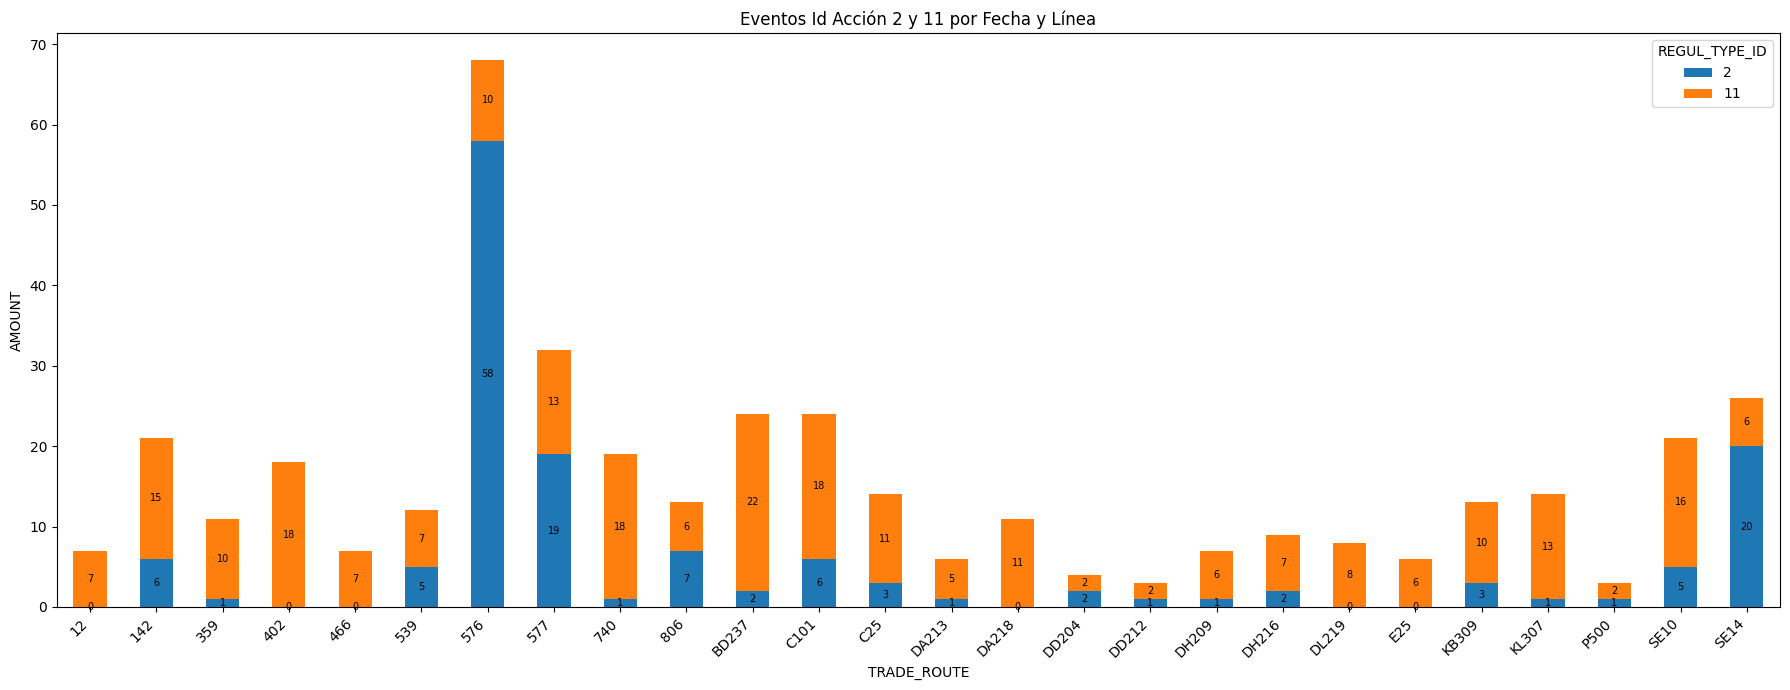

In [118]:
df_plot = (
    db_fms
    .groupby(['TRADE_ROUTE', 'REGUL_TYPE_ID'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# 🔹 Graficar
fig, ax = plt.subplots(figsize=(18,7))

df_plot.plot(kind='bar', stacked=True, ax=ax)

# 🔹 Etiquetas
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=7)

ax.set_title('Eventos Id Acción 2 y 11 por Fecha y Línea')
ax.set_xlabel('TRADE_ROUTE')
ax.set_ylabel('AMOUNT')
ax.legend(title='REGUL_TYPE_ID')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

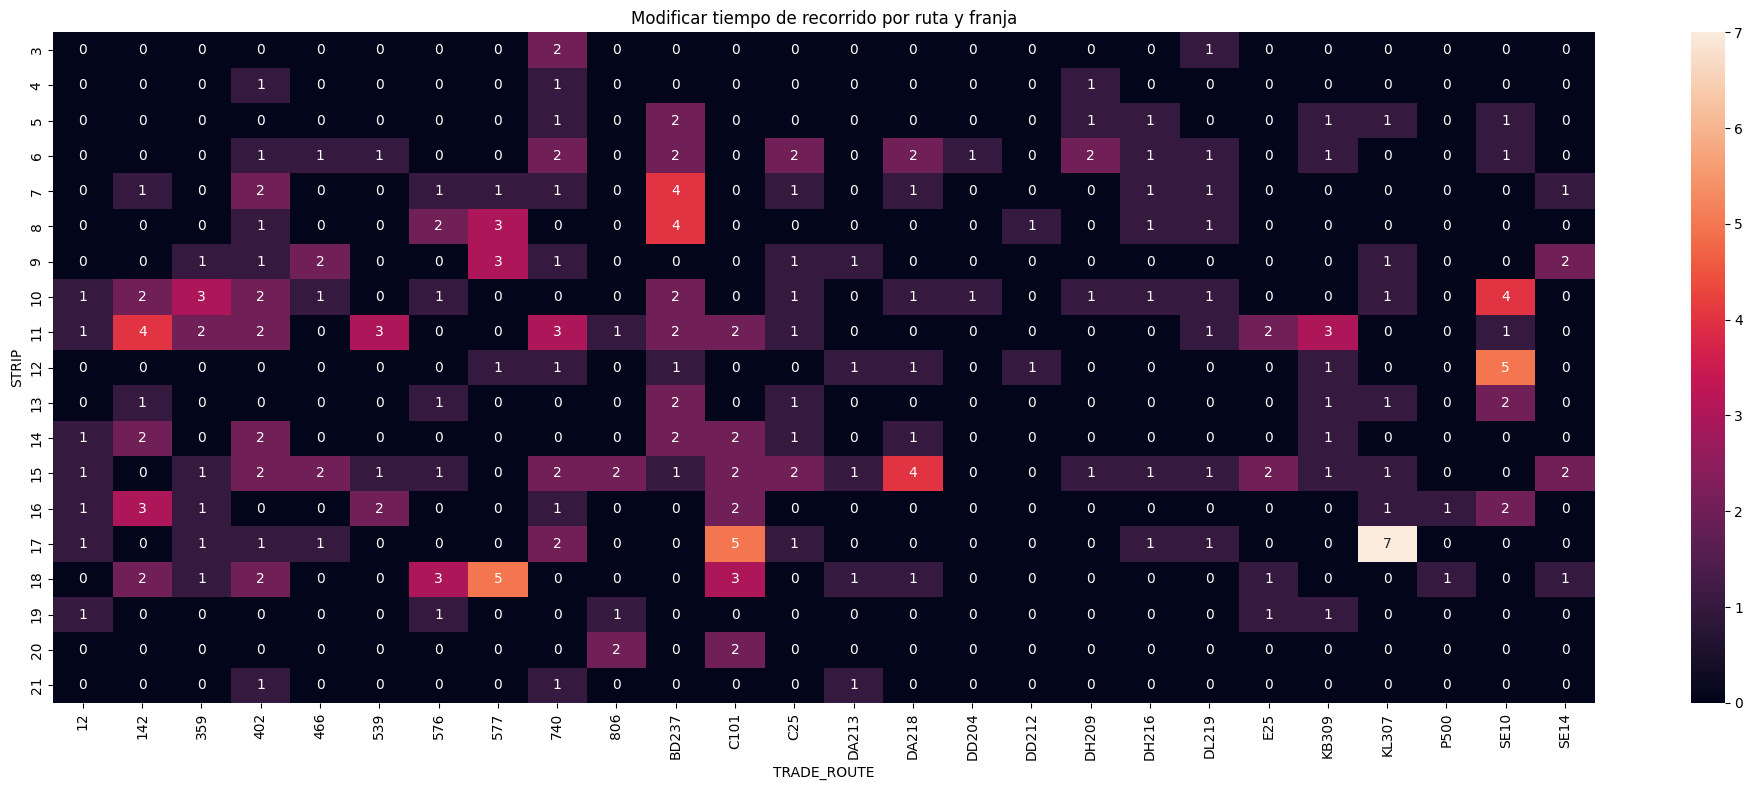

In [119]:
db_fms['STRIP'] = pd.to_numeric(db_fms['STRIP'], errors='coerce')

# 🔹 Crear pivot (invertido)
heatmap_data = (
    db_fms[db_fms['REGUL_TYPE_ID'] == 11]
    .groupby(['STRIP', 'TRADE_ROUTE'])
    .size()
    .unstack(fill_value=0)
)

# 🔹 Ordenar franjas de menor a mayor
heatmap_data = heatmap_data.sort_index()

# 🔹 Graficar
plt.figure(figsize=(20,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='g'
)

plt.title('Modificar tiempo de recorrido por ruta y franja')
plt.xlabel('TRADE_ROUTE')  
plt.ylabel('STRIP') 

plt.tight_layout()
plt.show()

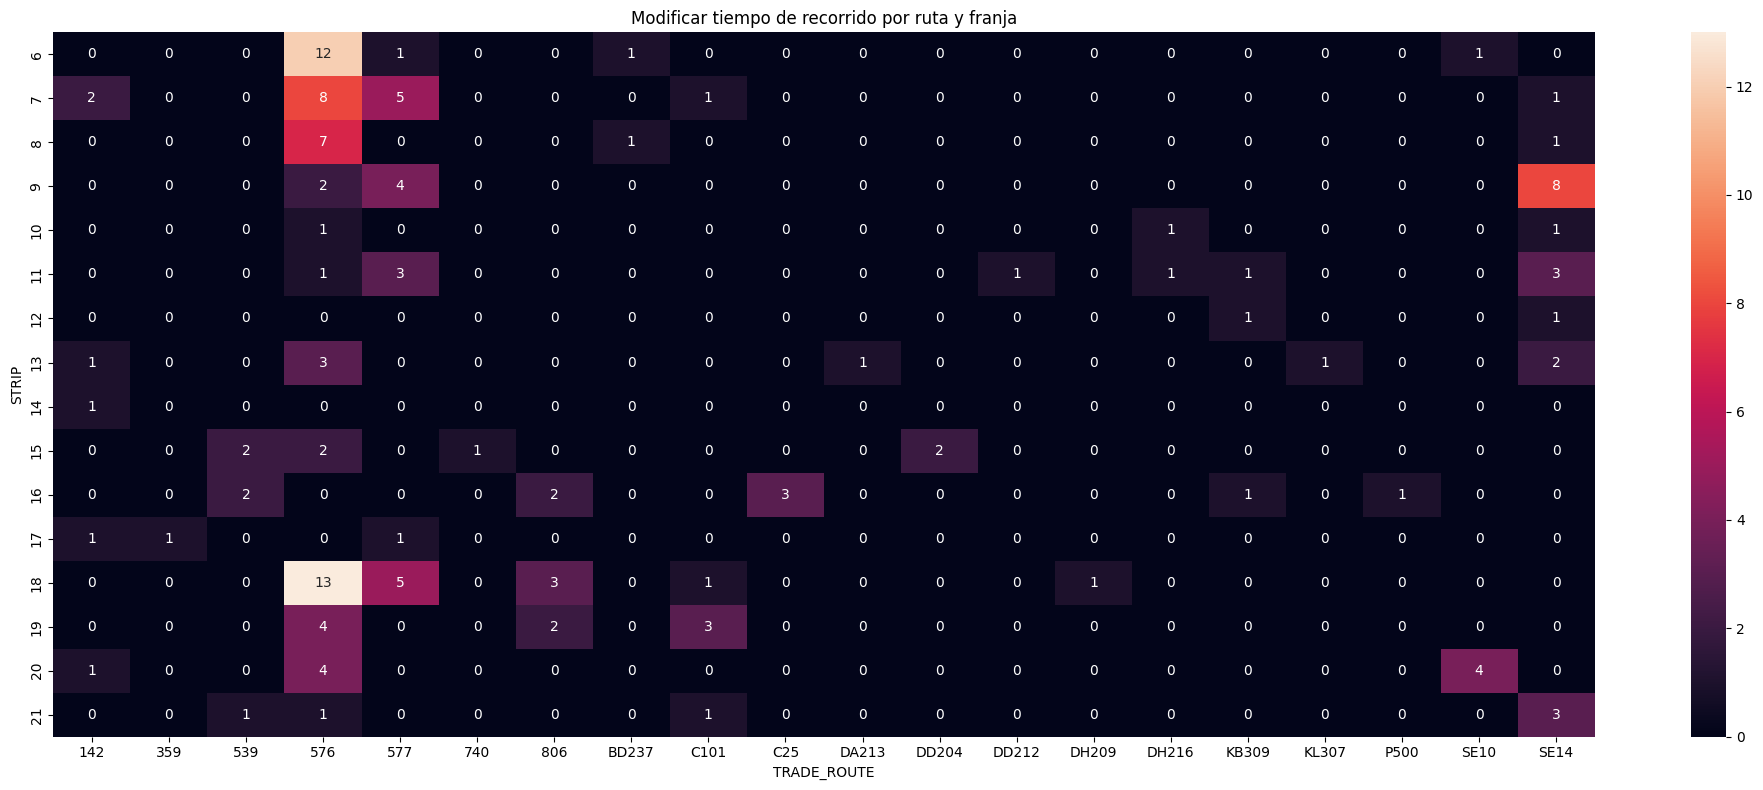

In [120]:
db_fms['STRIP'] = pd.to_numeric(db_fms['STRIP'], errors='coerce')

# 🔹 Crear pivot (invertido)
heatmap_data = (
    db_fms[db_fms['REGUL_TYPE_ID'] == 2]
    .groupby(['STRIP', 'TRADE_ROUTE'])
    .size()
    .unstack(fill_value=0)
)

# 🔹 Ordenar franjas de menor a mayor
heatmap_data = heatmap_data.sort_index()

# 🔹 Graficar
plt.figure(figsize=(20,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='g'
)

plt.title('Modificar tiempo de recorrido por ruta y franja')
plt.xlabel('TRADE_ROUTE')  
plt.ylabel('STRIP') 

plt.tight_layout()
plt.show()

In [121]:
heatmap_data = (
    db_fms[db_fms['REGUL_TYPE_ID'] == 11]
    .groupby(['STRIP', 'TRADE_ROUTE', 'FLAG_CATEGORY'])
    .size()
    .unstack(fill_value=0)
)

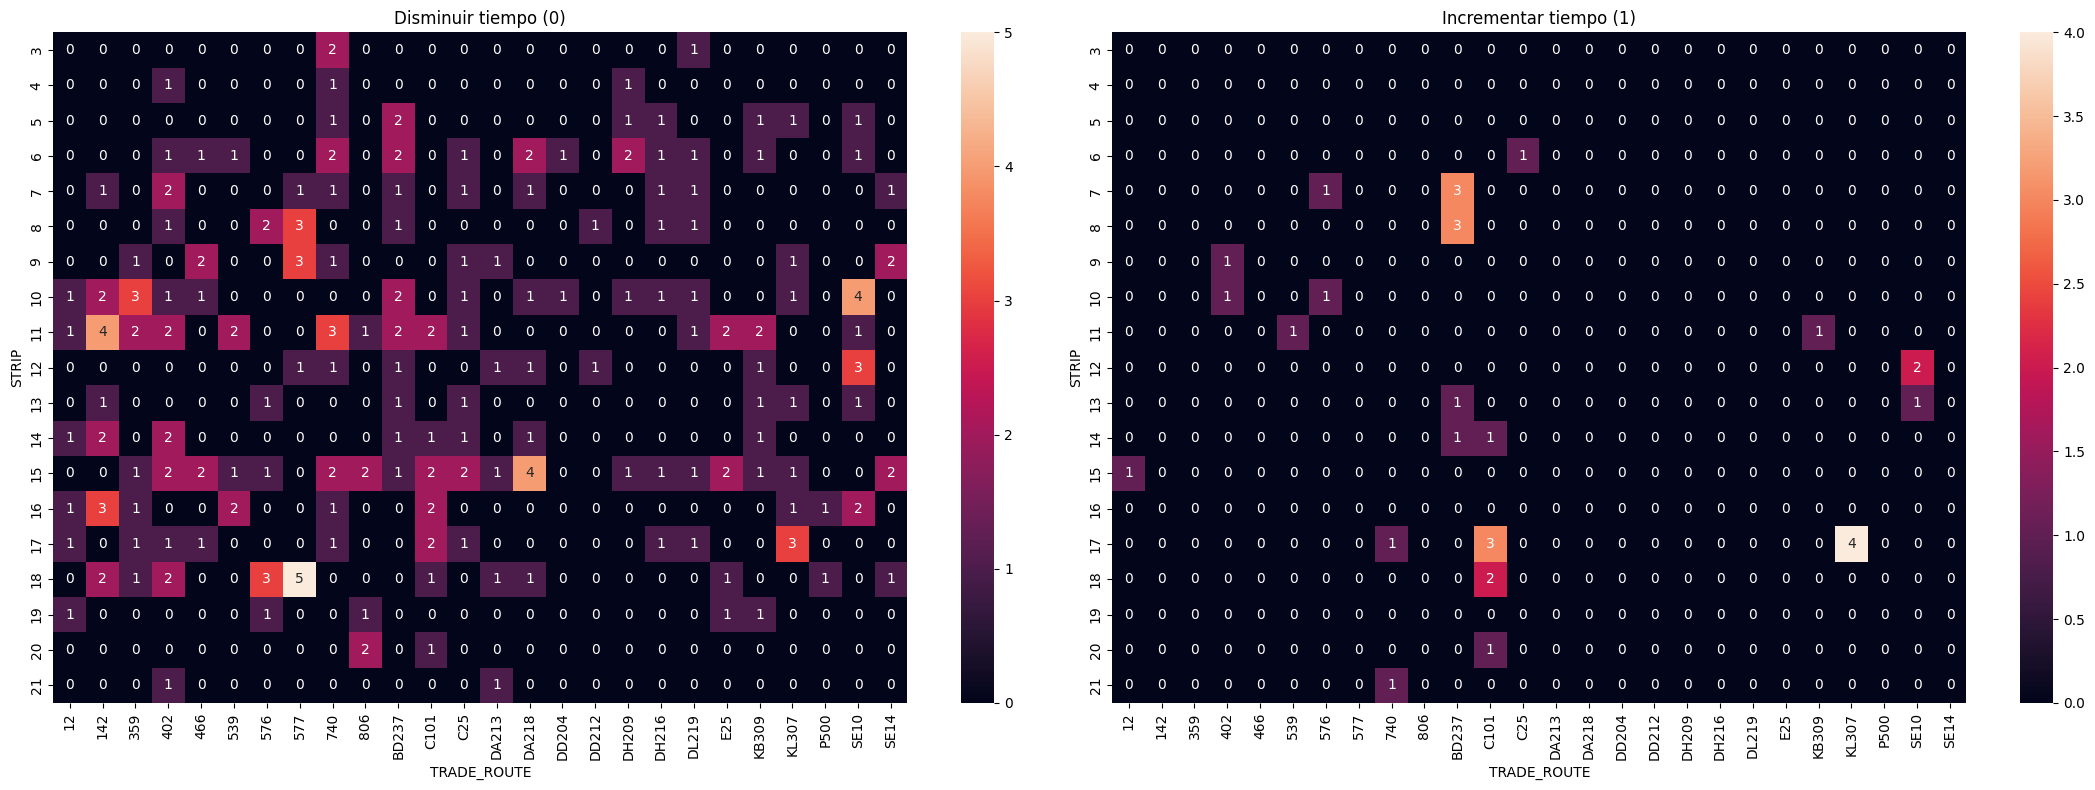

In [122]:
# 🔹 Separar
heat_0 = heatmap_data[0].unstack(fill_value=0)
heat_1 = heatmap_data[1].unstack(fill_value=0)

# 🔹 Ordenar
heat_0 = heat_0.sort_index()
heat_1 = heat_1.sort_index()

# 🔹 Gráfico
fig, axes = plt.subplots(1, 2, figsize=(22,8))

sns.heatmap(heat_0, annot=True, fmt='g', ax=axes[0])
axes[0].set_title('Disminuir tiempo (0)')
axes[0].set_xlabel('TRADE_ROUTE')
axes[0].set_ylabel('STRIP')

sns.heatmap(heat_1, annot=True, fmt='g', ax=axes[1])
axes[1].set_title('Incrementar tiempo (1)')
axes[1].set_xlabel('TRADE_ROUTE')
axes[1].set_ylabel('STRIP')

plt.tight_layout()
plt.show()

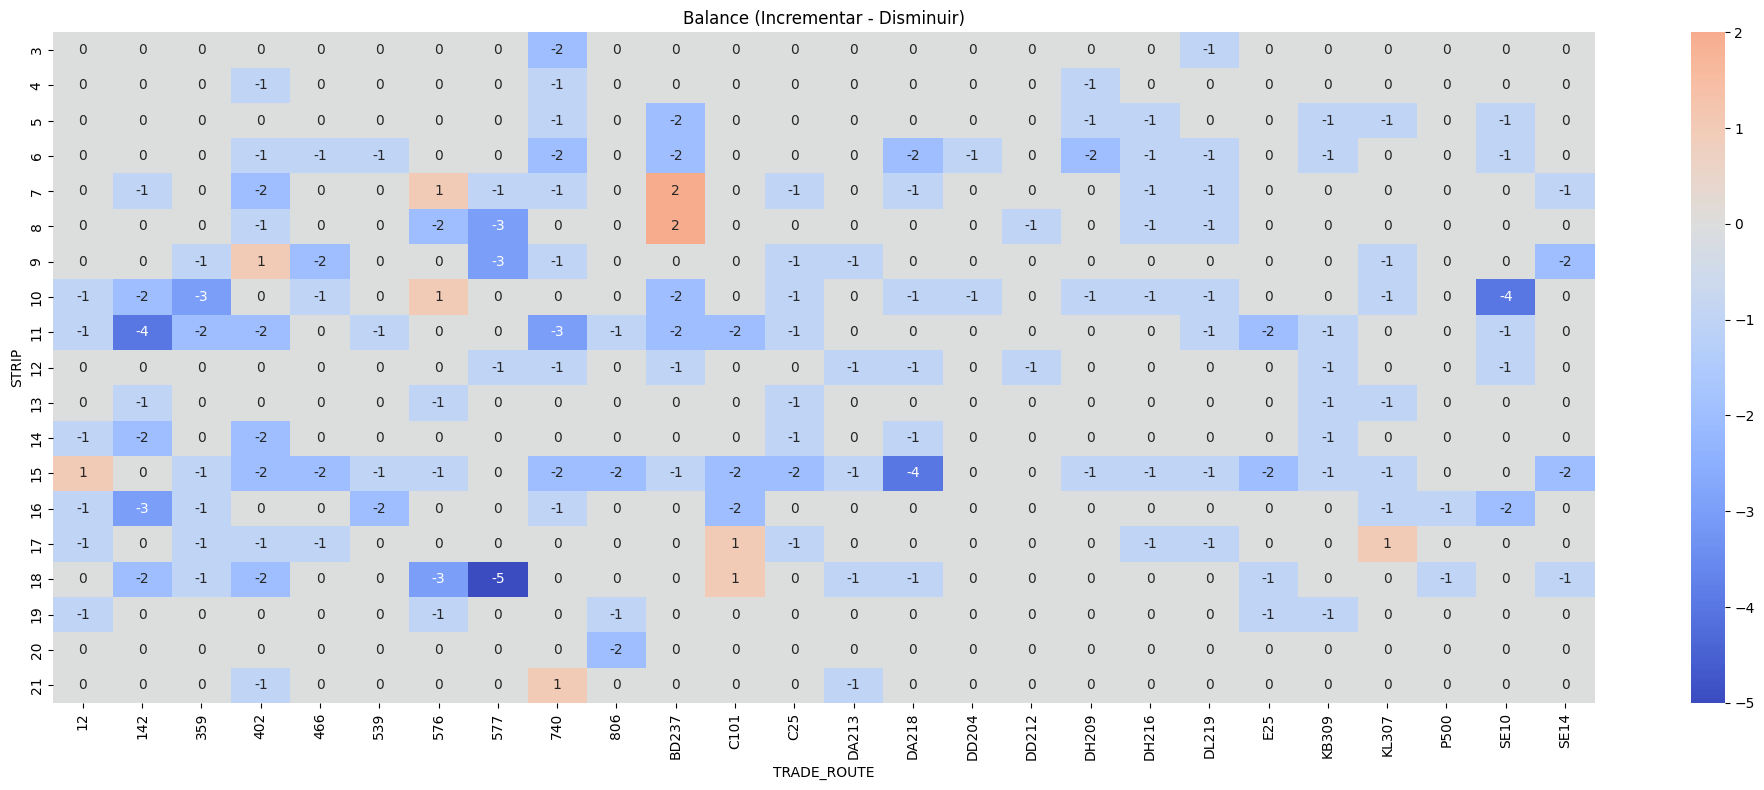

In [123]:
heat_diff = heat_1 - heat_0

plt.figure(figsize=(20,8))

sns.heatmap(heat_diff, annot=True, fmt='g', center=0, cmap='coolwarm')

plt.title('Balance (Incrementar - Disminuir)')
plt.xlabel('TRADE_ROUTE')
plt.ylabel('STRIP')

plt.tight_layout()
plt.show()

In [124]:
heatmap_data = (
    db_fms[db_fms['REGUL_TYPE_ID'] == 11]
    .groupby(['STRIP', 'TRADE_ROUTE', 'FLAG_CATEGORY'])
    .agg(
        cantidad=('FLAG_CATEGORY', 'size'),
        promedio_varation=('VARIATION', 'mean')
    )
    .reset_index()
)

heatmap_data.head()

,STRIP,TRADE_ROUTE,FLAG_CATEGORY,cantidad,promedio_varation
0,3,740,0,2,-30.0
1,3,DL219,0,1,-25.0
2,4,402,0,1,-30.0
3,4,740,0,1,-30.0
4,4,DH209,0,1,-20.0


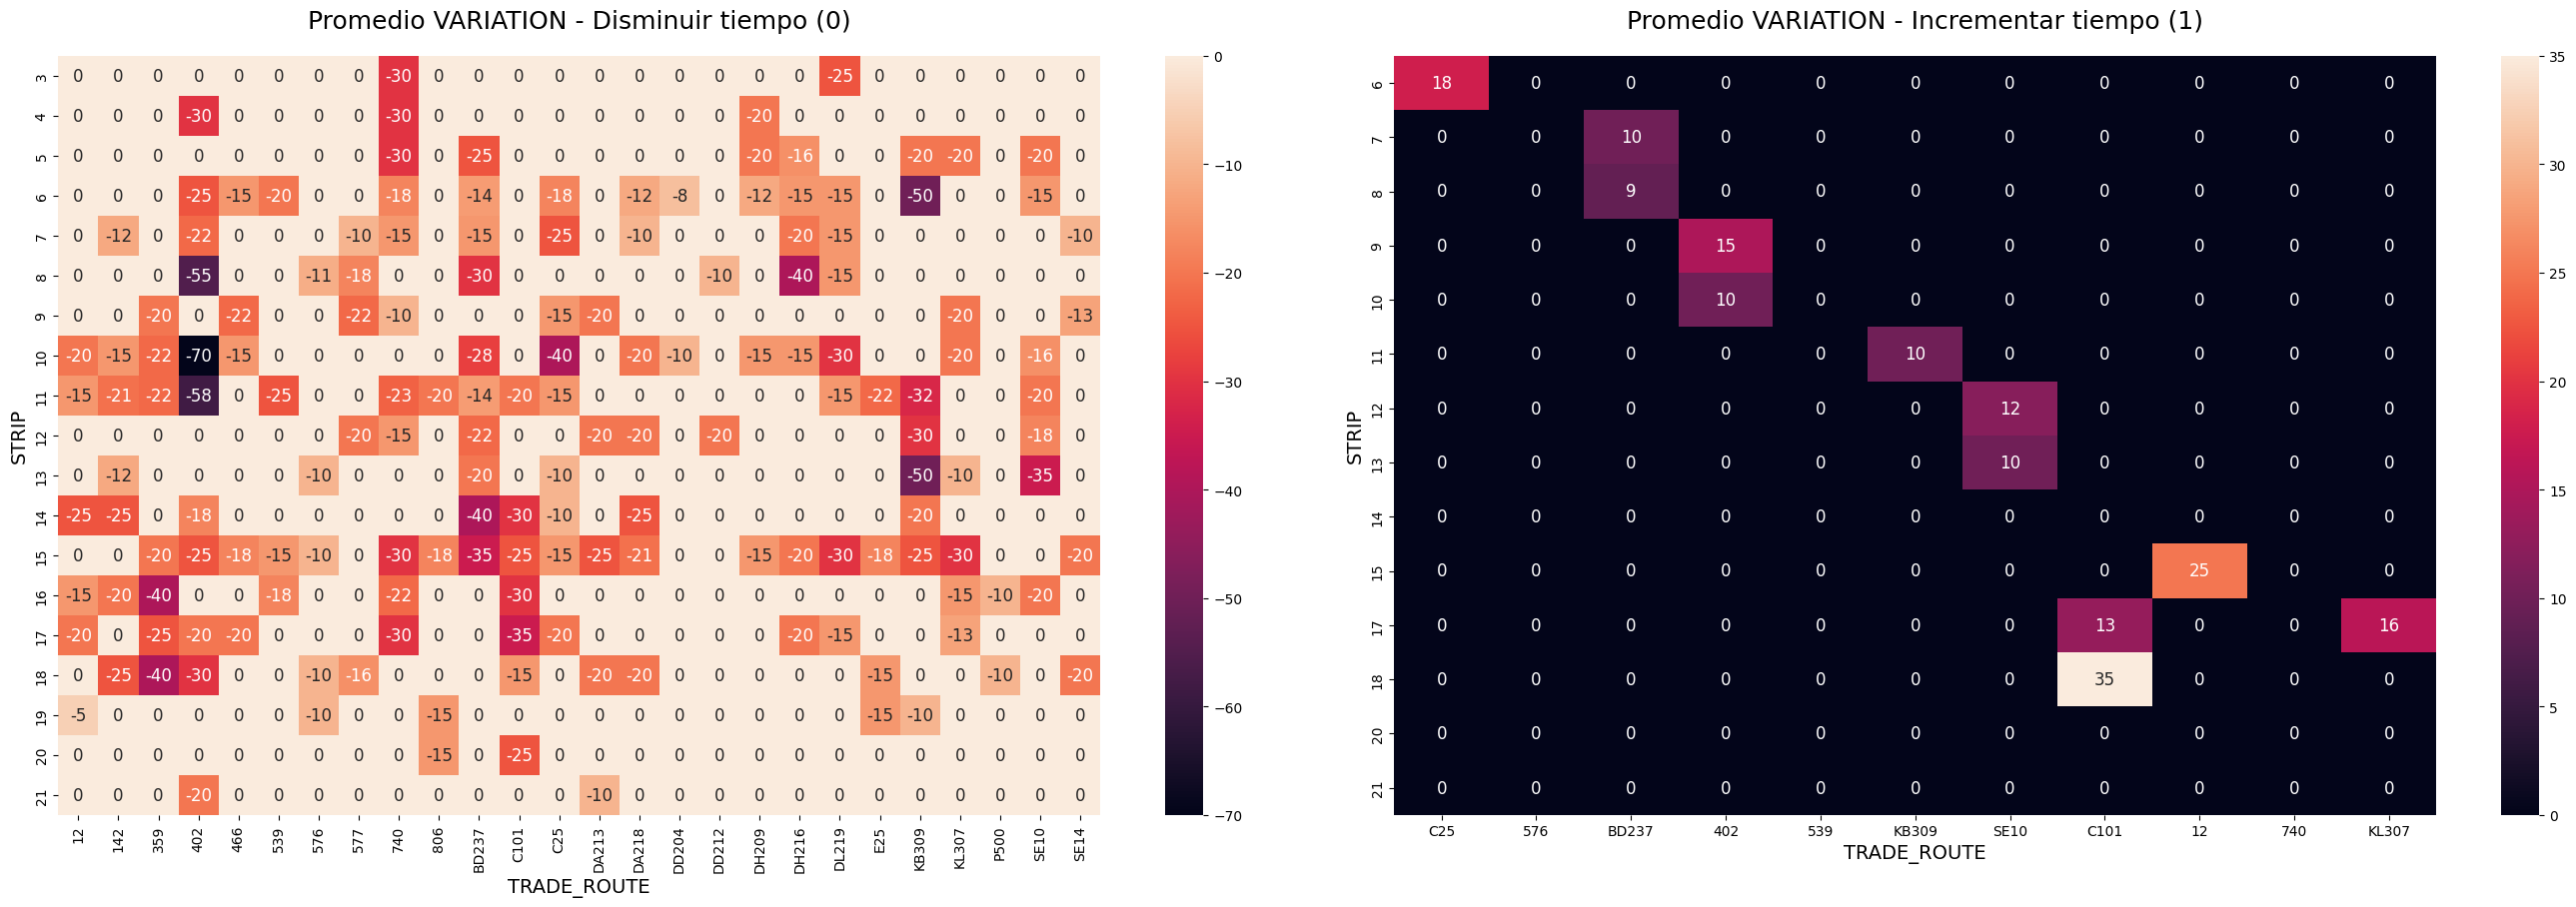

In [125]:
# 🔹 Promedio de VARIATION
heatmap_data = (
    db_fms[db_fms['REGUL_TYPE_ID'] == 11]
    .groupby(['STRIP', 'TRADE_ROUTE', 'FLAG_CATEGORY'])['VARIATION']
    .mean()
)

# 🔹 Separar por FLAG_CATEGORY
heat_0 = heatmap_data.xs(0, level='FLAG_CATEGORY').unstack(fill_value=0)
heat_1 = heatmap_data.xs(1, level='FLAG_CATEGORY').unstack(fill_value=0)

# 🔹 Ordenar
heat_0 = heat_0.sort_index()
heat_1 = heat_1.sort_index()

# 🔹 Convertir a enteros
heat_0 = heat_0.round(0).astype(int)
heat_1 = heat_1.round(0).astype(int)

# 🔹 Gráfico
fig, axes = plt.subplots(1, 2, figsize=(28,10))  # más grande

# 🔹 Heatmap 0
sns.heatmap(
    heat_0,
    annot=True,
    fmt='d',              # entero
    annot_kws={"size": 12}, # tamaño números
    ax=axes[0]
)

axes[0].set_title(
    'Promedio VARIATION - Disminuir tiempo (0)',
    fontsize=18,
    pad=20
)

axes[0].set_xlabel('TRADE_ROUTE', fontsize=14)
axes[0].set_ylabel('STRIP', fontsize=14)

# 🔹 Heatmap 1
sns.heatmap(
    heat_1,
    annot=True,
    fmt='d',
    annot_kws={"size": 12},
    ax=axes[1]
)

axes[1].set_title(
    'Promedio VARIATION - Incrementar tiempo (1)',
    fontsize=18,
    pad=20
)

axes[1].set_xlabel('TRADE_ROUTE', fontsize=14)
axes[1].set_ylabel('STRIP', fontsize=14)

plt.tight_layout(pad=4)
plt.show()


Acciones de regulación

In [126]:
# Ruta de la carpeta que contiene los archivos de desglosados troncal
ruta_carpeta = 'Z:/01 base_datos/09 acciones_regulacion_FMS'

# Fechas de inicio y fin para el filtro
fecha_inicio = f'{dia_ivd}'
fecha_fin = f'{dia_fvd}'

# Lista para almacenar los DataFrames
dataframes = []

# Recorrer todos los archivos en la carpeta
for nombre_archivo in os.listdir(ruta_carpeta):
    if nombre_archivo.endswith('_accionesregulacion.csv'):
        # Extraer la fecha del nombre del archivo
        fecha_archivo = nombre_archivo[:8]  
        
        # Convertir la fecha a un formato adecuado para comparación
        fecha_archivo_dt = pd.to_datetime(fecha_archivo, format='%Y%m%d', errors='coerce')

        # Verificar si la fecha está dentro del rango deseado
        if fecha_inicio <= fecha_archivo <= fecha_fin:
            ruta_archivo = os.path.join(ruta_carpeta, nombre_archivo)
            # Leer el archivo CSV omitiendo la primera fila vacía
            df = pd.read_csv(ruta_archivo, encoding='latin', low_memory=False)
             # Eliminar filas que estén completamente vacías
            df = df.dropna(how='all')
            dataframes.append(df)

# Verificar si se encontraron DataFrames
if dataframes:
    # Consolidar todos los DataFrames en uno solo
    acciones_fms = pd.concat(dataframes, ignore_index=True)

else:
    print("No se encontraron archivos para consolidar.")
    
acciones_fms.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
0,1/05/2026,1:19:38,10273,142,2.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
1,1/05/2026,1:20:17,10273,142,6.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
2,1/05/2026,1:21:08,10273,142,1.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
3,1/05/2026,1:21:55,10325,576,14.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
4,1/05/2026,1:23:10,10325,576,16.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN


In [127]:
acciones_fms = acciones_fms[acciones_fms['Id Acción'].isin([2, 11])]

acciones_fms['Cantidad'] = 1

acciones_fms.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,Cantidad
87,1/05/2026,4:52:41,10184,740,NaN,NaN,NaN,11,Modificar Tiempo de Recorrido,NNINO_105,NORBERTO NIÑO NIÑO RODRIGUEZ,"<= Modify Journey Time =>\nApplyDate=20260501,...",12,Solicitud del area de programacion,NaN,1
109,1/05/2026,6:10:59,10325,576,NaN,NaN,NaN,2,Desfase Instantaneo,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,"<= Instant Gap =>\nApplyDate=20260501,\nIdLine...",12,Solicitud del area de programacion,NaN,1
110,1/05/2026,6:11:14,10325,576,NaN,NaN,NaN,2,Desfase Instantaneo,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,"<= Instant Gap =>\nApplyDate=20260501,\nIdLine...",12,Solicitud del area de programacion,NaN,1
112,1/05/2026,6:11:57,10325,576,NaN,NaN,NaN,2,Desfase Instantaneo,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,"<= Instant Gap =>\nApplyDate=20260501,\nIdLine...",12,Solicitud del area de programacion,NaN,1
113,1/05/2026,6:12:11,10325,576,NaN,NaN,NaN,2,Desfase Instantaneo,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,"<= Instant Gap =>\nApplyDate=20260501,\nIdLine...",12,Solicitud del area de programacion,NaN,1


In [128]:
acciones_fms['Franja'] = acciones_fms['Instante'].astype(str).str.split(':').str[0]

acciones_fms.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,Cantidad,Franja
87,1/05/2026,4:52:41,10184,740,NaN,NaN,NaN,11,Modificar Tiempo de Recorrido,NNINO_105,NORBERTO NIÑO NIÑO RODRIGUEZ,"<= Modify Journey Time =>\nApplyDate=20260501,...",12,Solicitud del area de programacion,NaN,1,4
109,1/05/2026,6:10:59,10325,576,NaN,NaN,NaN,2,Desfase Instantaneo,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,"<= Instant Gap =>\nApplyDate=20260501,\nIdLine...",12,Solicitud del area de programacion,NaN,1,6
110,1/05/2026,6:11:14,10325,576,NaN,NaN,NaN,2,Desfase Instantaneo,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,"<= Instant Gap =>\nApplyDate=20260501,\nIdLine...",12,Solicitud del area de programacion,NaN,1,6
112,1/05/2026,6:11:57,10325,576,NaN,NaN,NaN,2,Desfase Instantaneo,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,"<= Instant Gap =>\nApplyDate=20260501,\nIdLine...",12,Solicitud del area de programacion,NaN,1,6
113,1/05/2026,6:12:11,10325,576,NaN,NaN,NaN,2,Desfase Instantaneo,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,"<= Instant Gap =>\nApplyDate=20260501,\nIdLine...",12,Solicitud del area de programacion,NaN,1,6


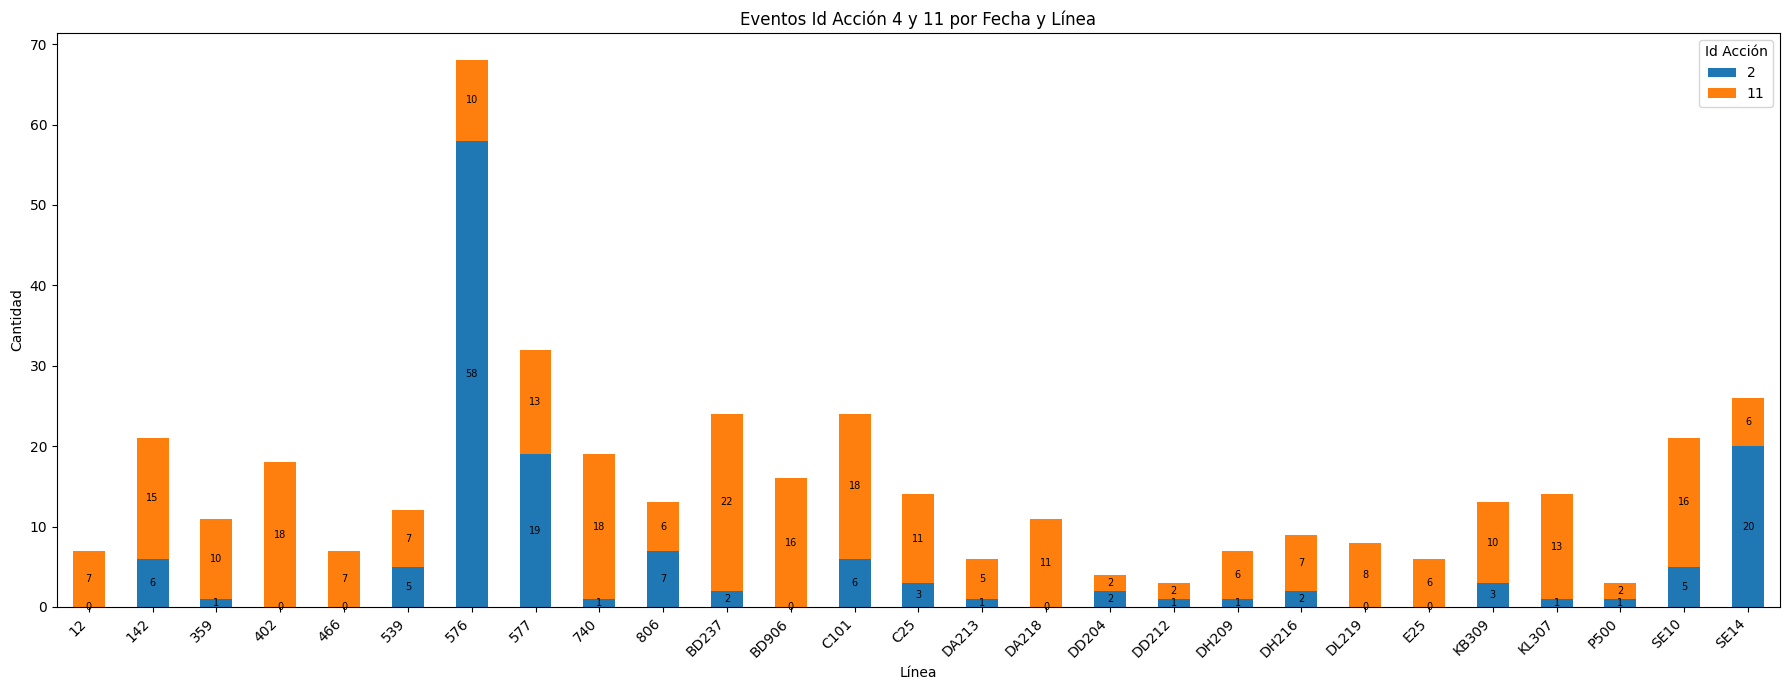

In [129]:
# 🔹 Fecha a datetime
acciones_fms['Fecha'] = pd.to_datetime(acciones_fms['Fecha'], dayfirst=True, errors='coerce')

df_plot = (
    acciones_fms
    .groupby(['Línea', 'Id Acción'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# 🔹 Graficar
fig, ax = plt.subplots(figsize=(18,7))

df_plot.plot(kind='bar', stacked=True, ax=ax)

# 🔹 Etiquetas
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=7)

ax.set_title('Eventos Id Acción 4 y 11 por Fecha y Línea')
ax.set_xlabel('Línea')
ax.set_ylabel('Cantidad')
ax.legend(title='Id Acción')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

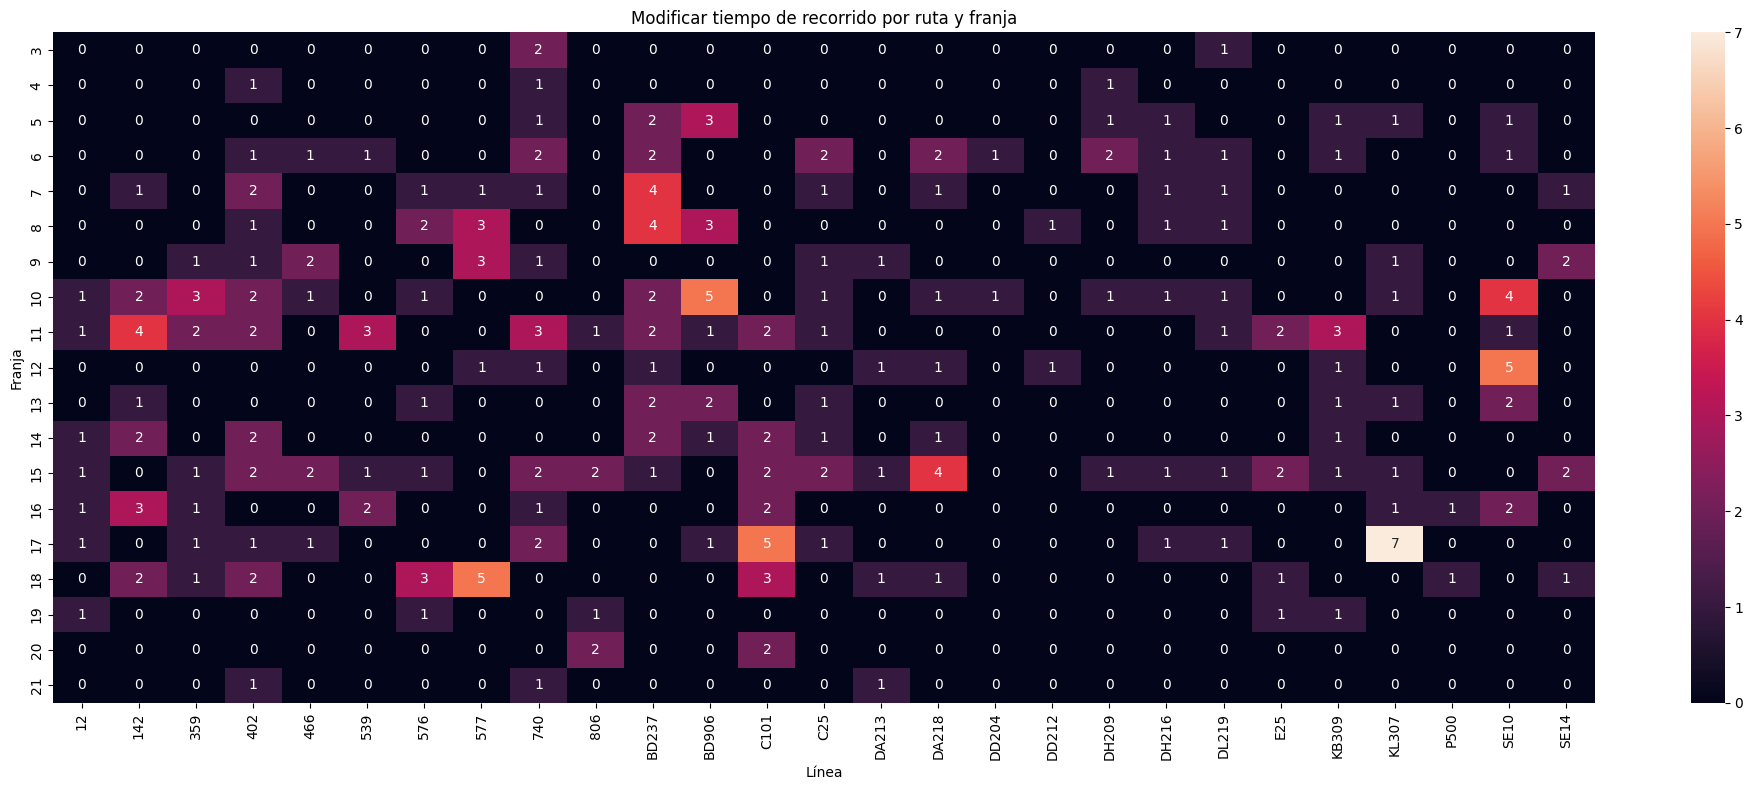

In [130]:
acciones_fms['Franja'] = pd.to_numeric(acciones_fms['Franja'], errors='coerce')

# 🔹 Crear pivot (invertido)
heatmap_data = (
    acciones_fms[acciones_fms['Id Acción'] == 11]
    .groupby(['Franja', 'Línea'])
    .size()
    .unstack(fill_value=0)
)

# 🔹 Ordenar franjas de menor a mayor
heatmap_data = heatmap_data.sort_index()

# 🔹 Graficar
plt.figure(figsize=(20,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='g'
)

plt.title('Modificar tiempo de recorrido por ruta y franja')
plt.xlabel('Línea')  
plt.ylabel('Franja') 

plt.tight_layout()
plt.show()

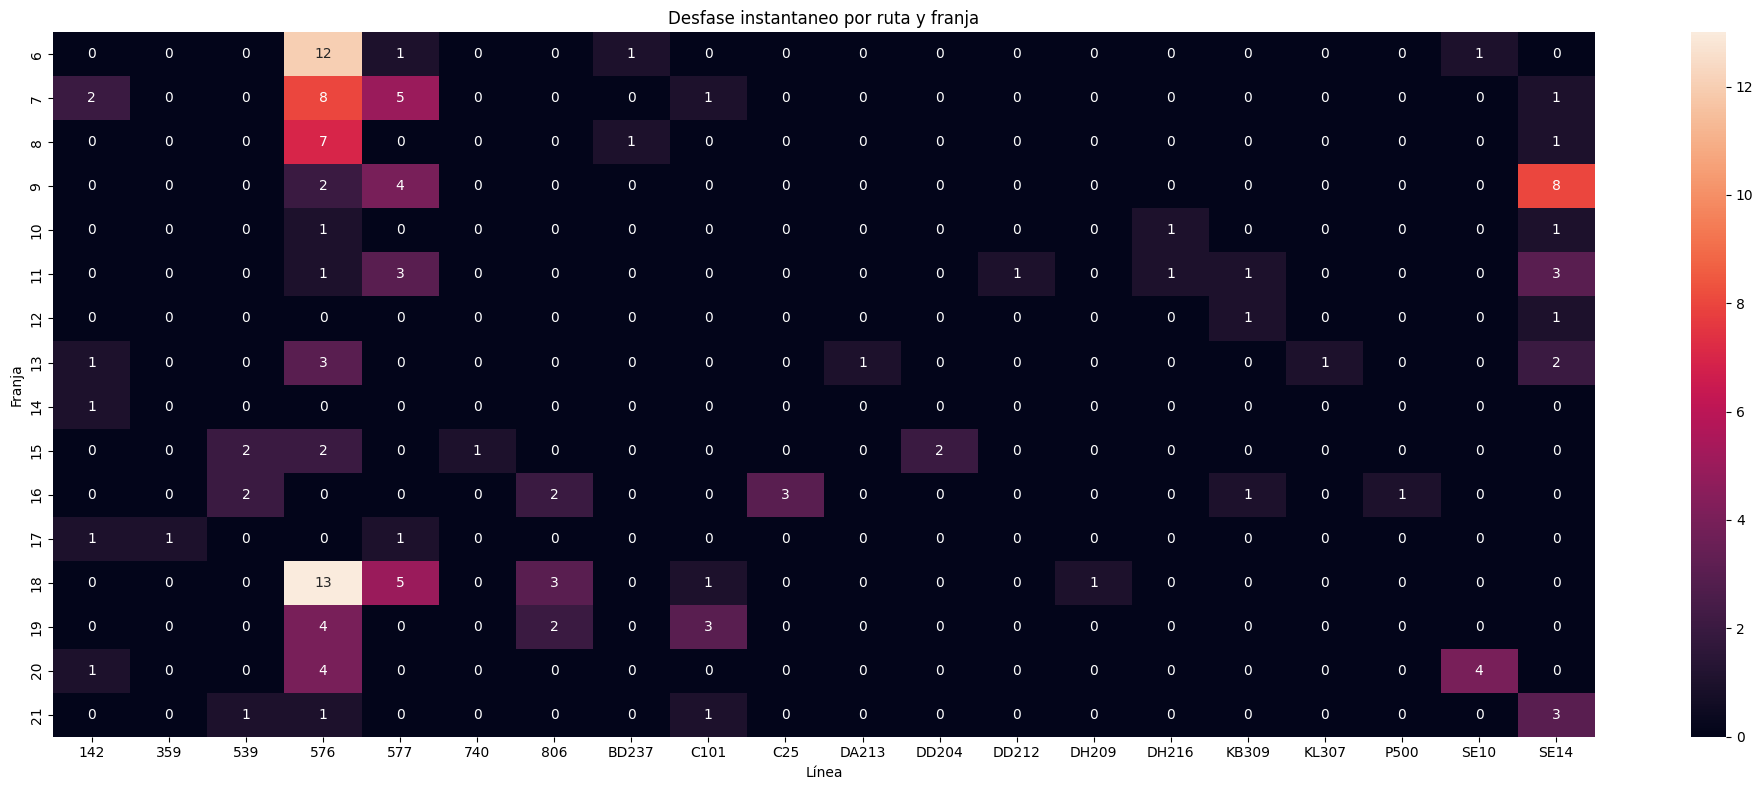

In [131]:
# 🔹 Crear pivot (invertido)
heatmap_data = (
    acciones_fms[acciones_fms['Id Acción'] == 2]
    .groupby(['Franja', 'Línea'])
    .size()
    .unstack(fill_value=0)
)

# 🔹 Ordenar franjas de menor a mayor
heatmap_data = heatmap_data.sort_index()

# 🔹 Graficar
plt.figure(figsize=(20,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='g'
)

plt.title('Desfase instantaneo por ruta y franja')
plt.xlabel('Línea')  
plt.ylabel('Franja') 

plt.tight_layout()
plt.show()

In [132]:
#Exportar datos
acciones_fms.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Acciones/{mes}_acciones_reg.csv', index=False, sep=';')

In [133]:
db_fms.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Acciones/{mes}_acciones_reg_db.csv', index=False, sep=';')

In [134]:
df_fms_con.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Acciones/{mes}_acciones_reg_comportamiento.csv', index=False, sep=';')

In [135]:
df_fms_con.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Acciones/{mes}_acciones_reg_comportamiento1.csv', index=False, sep=';')